In [2]:
# Core data manipulation & analysis
import pandas as pd
import numpy as np

# Preprocessing & modeling
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence
import joblib


In [3]:
# Reading large CSV files in chunks helps manage memory usage
chunksize = 10000  # Adjust this based on available system RAM
chunks = []

# Replace 'big5_data.csv' with your actual file path
for chunk in pd.read_csv('big5_data.csv', sep='\t', chunksize=chunksize):
    chunks.append(chunk)

# Concatenate all chunks into a single DataFrame
df = pd.concat(chunks, ignore_index=True)

# Quick sanity check
df.head()


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [4]:
# Create column name lists for each Big Five trait dimension
ext_cols = [f'EXT{i}' for i in range(1, 11)]
est_cols = [f'EST{i}' for i in range(1, 11)]
agr_cols = [f'AGR{i}' for i in range(1, 11)]
csn_cols = [f'CSN{i}' for i in range(1, 11)]
opn_cols = [f'OPN{i}' for i in range(1, 11)]

# Combine all into one list for easier processing
trait_cols = ext_cols + est_cols + agr_cols + csn_cols + opn_cols

# Check if all expected columns exist in the dataset
missing_cols = [col for col in trait_cols if col not in df.columns]
if missing_cols:
    print("⚠️ Missing columns:", missing_cols)
else:
    print("✅ All trait columns found.")


✅ All trait columns found.


In [5]:
# Replace missing values with the column mean
# This is a simple and effective strategy for numerical personality data
imputer = SimpleImputer(strategy='mean')
df[trait_cols] = imputer.fit_transform(df[trait_cols])

# Confirm there are no remaining NaNs in the trait columns
df[trait_cols].isna().sum().sum()


0

In [6]:
# Aggregate the 10 items per trait into a single mean score for each trait
df['Extraversion']       = df[ext_cols].mean(axis=1)
df['Neuroticism']        = df[est_cols].mean(axis=1)
df['Agreeableness']      = df[agr_cols].mean(axis=1)
df['Conscientiousness']  = df[csn_cols].mean(axis=1)
df['Openness']           = df[opn_cols].mean(axis=1)

In [7]:
# Standardize the OCEAN features to have zero mean and unit variance
features = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])


In [ ]:
# MiniBatchKMeans is more efficient for large datasets than standard KMeans
kmeans = MiniBatchKMeans(
    n_clusters=4,       # Number of personality archetypes to find
    batch_size=10000, 
    random_state=42
)

# Assign each respondent to a cluster
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Get cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)

print("📌 Cluster Centers (Original Scale):")
display(centroids_df)


📌 Cluster Centers (Original Scale):


,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
0,3.184321,3.673923,3.505652,3.368080,3.381691
1,2.788546,3.412058,2.991805,3.178773,3.346490
2,3.248436,2.603112,3.215848,3.210399,3.358470
3,2.857694,2.553130,2.944773,2.743366,2.966189


In [10]:
# These mappings are heuristic — adjust them after reviewing centroids_df
archetype_map = {
    0: 'Average',        # Medium traits
    1: 'Reserved',       # Low Extraversion/Openness, low Neuroticism
    2: 'Role Model',     # High positive traits, low Neuroticism
    3: 'Self-Centered'   # High Extraversion, low Agreeableness/Conscientiousness
}

# Map each cluster label to a descriptive personality type
df['PersonalityType'] = df['Cluster'].map(archetype_map)

# Quick check of distribution
df['PersonalityType'].value_counts()


PersonalityType
Role Model       306650
Reserved         268572
Self-Centered    220769
Average          219350
Name: count, dtype: int64

In [ ]:
# Split data into train and test sets
X = df[features]
y = df['PersonalityType']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate performance
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


✅ Accuracy: 0.9931845825803052

📊 Classification Report:
               precision    recall  f1-score   support

      Average       0.99      0.99      0.99     43519
     Reserved       0.99      0.99      0.99     53799
   Role Model       0.99      0.99      0.99     61594
Self-Centered       0.99      0.99      0.99     44157

     accuracy                           0.99    203069
    macro avg       0.99      0.99      0.99    203069
 weighted avg       0.99      0.99      0.99    203069



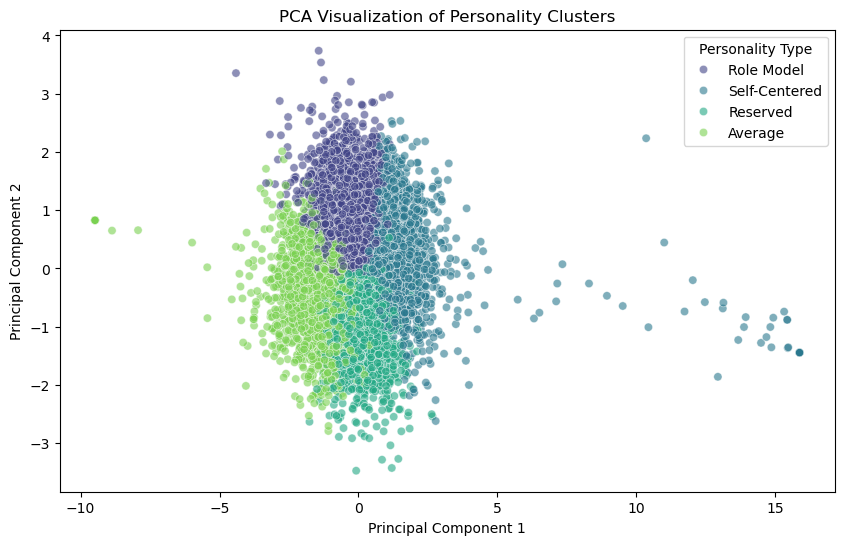

In [12]:
# Reduce dimensionality to 2D for visualization
sample_size = 10000  # Subsample to speed up plotting
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled[:sample_size])

# Plot clusters in 2D space
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=reduced[:, 0],
    y=reduced[:, 1],
    hue=df['PersonalityType'][:sample_size],
    palette='viridis',
    alpha=0.6
)
plt.title('PCA Visualization of Personality Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Personality Type')
plt.show()


In [13]:
# Save trained models for later use
joblib.dump(clf, 'personality_classifier.pkl')
joblib.dump(scaler, 'personality_scaler.pkl')
joblib.dump(kmeans, 'personality_kmeans.pkl')

print("✅ Models saved successfully.")


✅ Models saved successfully.


In [16]:
import joblib  # Use joblib instead of pickle

def load_models():
    global classifier, scaler, kmeans
    try:
        # Use joblib.load() since models were saved with joblib.dump()
        classifier = joblib.load('personality_classifier.pkl')
        scaler = joblib.load('personality_scaler.pkl')
        kmeans = joblib.load('personality_kmeans.pkl')
        print("Models loaded successfully!")
    except FileNotFoundError as e:
        print(f"Warning: Model file not found - {e}")
        print("Please ensure personality_classifier.pkl, personality_scaler.pkl, and personality_kmeans.pkl are in the project directory")

# Initialize global variables before calling load_models()
classifier = None
scaler = None
kmeans = None

load_models()


Models loaded successfully!
